## Final Project: Large-Scale Video Game Recommendation System Using Apache Spark  

**Course:** DATA 612 – Recommender Systems<br>
**Student:** Inna Yedzinovich

## Final Project Outline

### Project Title

#### Large-Scale Video Game Recommendation System Using Spark, Deep Learning, and Azure

### Project Overview

The goal of this project is to build a large-scale video game recommendation system using the Amazon Reviews 2023 Video Games dataset.

Collaborative filtering, content-based recommendation, deep learning, and cloud deployment will be explored. The results from each model will be compared to determine whether combining multiple recommendation approaches improves recommendation quality.

The project will use:

- Databricks for Spark processing and collaborative filtering
- Jupyter Notebook for data analysis, visualizations, deep learning, and the hybrid model
- Microsoft Azure for cloud deployment

### Dataset

The Amazon Reviews 2023 Video Games dataset will be used.

- 2.8 million users
- 137 thousand items
- 4.6 million ratings

The size of the dataset makes it suitable for Spark-based processing and recommendation modeling.

### Phase 1: Data Preparation and Exploration (Databricks and Jupyter)

- Load and clean the data
- Prepare user, item, and rating information
- Explore users, ratings, and products
- Create summary statistics and visualizations

**Question:** What characteristics of the data may affect recommendation performance?

### Phase 2: Collaborative Filtering with Spark (Databricks)

- Prepare user-item interaction data
- Build a recommendation model using Spark ALS
- Generate recommendations
- Evaluate model accuracy

**Question:** How well does collaborative filtering perform on this dataset?

### Phase 3: Deep Learning Content Model (Jupyter)

- Prepare metadata features
- Build a neural network using PyTorch
- Learn item embeddings from metadata
- Generate content-based recommendations

**Question:** Can meaningful item relationships be learned from metadata alone?

### Phase 4: Hybrid Recommendation System (Jupyter)

- Combine ALS predictions and content-based similarity scores
- Generate hybrid recommendations
- Compare recommendation results across models

**Question:** Does a hybrid recommendation model improve recommendation quality?

### Phase 5: Evaluation (Jupyter)

Evaluate the models using:

- RMSE
- Coverage
- Diversity
- Novelty

Compare:

- Spark ALS
- Deep Learning Content Model
- Hybrid Model

**Question:** Do the results support the expected outcome?

### Phase 6: Azure Deployment (Azure)

Deploy recommendation system components using:

- Azure Blob Storage
- Azure Functions
- Azure Virtual Network and Network Security Group

**Question:** What are the benefits and challenges of deploying a recommendation system in the cloud?

### Expected Outcome

The hybrid model is expected to provide the strongest overall recommendation performance by combining user behavior and item metadata. This assumption will be evaluated by comparing the collaborative filtering, content-based, and hybrid models using multiple recommendation metrics.

### Phase 1: Data Preparation and Exploration (Databricks and Jupyter)

The first phase focuses on preparing and exploring the data.

User, item, rating, and metadata information will be loaded and cleaned. Rating distributions, user activity, item popularity, and missing values will be examined to better understand the dataset.

Databricks will be used for Spark processing, and Jupyter Notebook will be used for analysis, visualizations, and documentation.

The results from this phase will be used in the recommendation models developed later in the project.

**Research Question:** What characteristics of the data may impact recommendation performance?

#### Creating a Working Dataset

The original Video Games dataset contains approximately 4.6 million ratings and more than 2.66 GB of data. To make the project easier to manage, a subset containing 3 million ratings was created.

The subset exceeds the project requirement of 1 million ratings and remains large enough for Spark-based recommendation modeling.

A smaller dataset was also needed because the original dataset could not be loaded directly through the available Databricks API, and Databricks limits local file uploads used for table creation to 2 GB. Reducing the dataset size made the data easier to upload and process while preserving the scale of the recommendation problem.

In [1]:
# imports
!pip install pandas numpy matplotlib scikit-learn torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


#### Metadata Selection

The original metadata file contains many fields that are not needed for recommendation modeling, including images, videos, and product details.

To simplify the dataset, only the fields used in later phases of the project were retained:

- parent_asin
- title
- description
- categories
- average_rating
- rating_number
- price
- store
- main_category

These fields provide the metadata used for the content-based, deep learning, and hybrid recommendation models.

#### Loading the Project Data

After the datasets were uploaded to Databricks, two Spark tables were created:

- `video_games_3_m` (review data)
- `meta_video_games` (metadata)

The review table contains user ratings and interactions, while the metadata table contains product information such as titles, descriptions, categories, and popularity measures.

The two tables will later be joined using `parent_asin` to support the content-based, deep learning, and hybrid recommendation models.

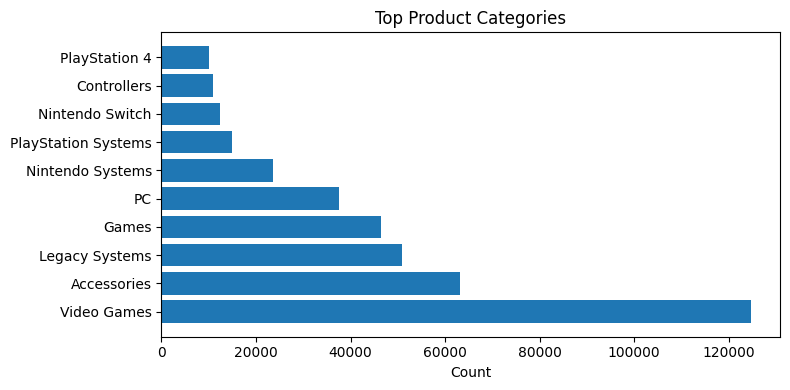

In [2]:
from IPython.display import Image
Image("data/plot-1.png")

Image("data/plot-2.png")

#### Initial Dataset Summary

After the review and metadata datasets were loaded and joined, the final dataset contained 3 million ratings, approximately 1.59 million users, and 121 thousand items.

The ratings were heavily skewed toward positive reviews, with most interactions receiving a 5-star rating. Missing values were limited and were mainly found in optional fields such as price, store, and main category.

The resulting dataset provides the user, item, rating, and metadata information needed for the recommendation models developed in later phases.

#### User and Item Activity

User activity and item popularity were examined to understand how ratings are distributed across the dataset.

The results showed that activity is uneven. Some users contributed many ratings, while most users provided only a few. A similar pattern was observed for items, where a small number of products received many ratings and most products received relatively few.

This imbalance is common in recommendation datasets and may affect model performance, particularly for products with limited rating history.

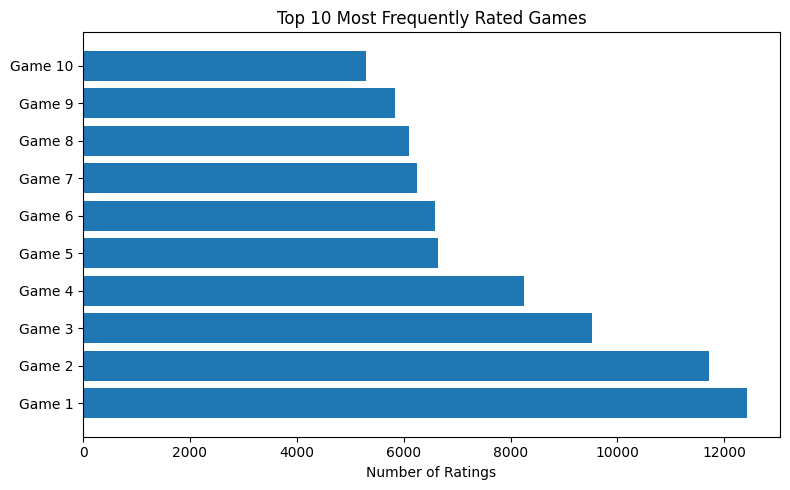

In [3]:
display(Image("data/plot-3.png"))

#### User Activity Distribution

The number of ratings submitted by each user was examined.

User activity was highly uneven. More than one million users submitted only one rating, and approximately 94% of users submitted fewer than five ratings.

These results indicate a highly sparse user-item matrix, where most users contribute very little interaction data. This is important because collaborative filtering models rely on user-item interactions to learn recommendation patterns.

#### Phase 1 Findings

The review and metadata datasets were loaded, cleaned, and joined for recommendation modeling.

The final dataset contains:

- 3,000,000 ratings
- 1,589,191 users
- 121,070 items
- 137,269 items with metadata

Most ratings are 5-star reviews, resulting in a highly positive rating distribution.

The dataset contains both video games and gaming-related products, including accessories, controllers, memberships, and gift cards.

Item popularity is uneven, with a small number of items receiving many ratings and most items receiving relatively few.

User activity is also uneven. More than one million users submitted only one rating, and approximately 94% of users submitted fewer than five ratings, resulting in a highly sparse user-item matrix.

Missing values were limited and were mainly found in optional metadata fields such as price, store, and main category.

#### Research Question

**What characteristics of the data may impact recommendation performance?**

Several characteristics that may affect recommendation performance were identified:

- Ratings are heavily skewed toward positive reviews.
- User activity is uneven.
- The user-item matrix is highly sparse.
- Item popularity is concentrated among a small number of items.
- The dataset contains both video games and gaming-related products.
- Some optional metadata fields contain missing values.

These characteristics should be considered when developing and evaluating the recommendation models.

### Phase 2: Collaborative Filtering with Spark (Databricks)

In this phase, a collaborative filtering recommendation model will be built using Spark ALS (Alternating Least Squares).

The model will be trained using user-item-rating interactions from the review dataset. Unlike content-based recommendation methods, ALS uses only user behavior and rating information to generate recommendations.

Because Phase 1 showed that the dataset is highly sparse, inactive users and items will be filtered before model training. This step is intended to reduce sparsity and improve the quality of the learned user-item relationships.

The ALS model will be used as a baseline and will later be compared with the deep learning and hybrid recommendation models.

Planned steps:

- Filter inactive users and items
- Prepare user-item-rating data
- Train a Spark ALS model
- Generate recommendations
- Evaluate model performance

**Research Question:** How well does collaborative filtering perform on this dataset?

#### ALS Data Preparation

Phase 1 showed that the dataset is highly sparse, with many users and products having very few interactions.

To reduce sparsity, users with fewer than five ratings and products with fewer than five ratings were removed before training the ALS model.

This filtering step reduced the number of low-activity records and retained users and products with sufficient interaction history for collaborative filtering.

This resulted in a dataset containing:

- 826,884 ratings
- 95,904 users
- 46,517 items

The filtered dataset remained large enough for Spark processing while reducing sparsity. The resulting user-item matrix contained more interaction information and was better suited for ALS training.

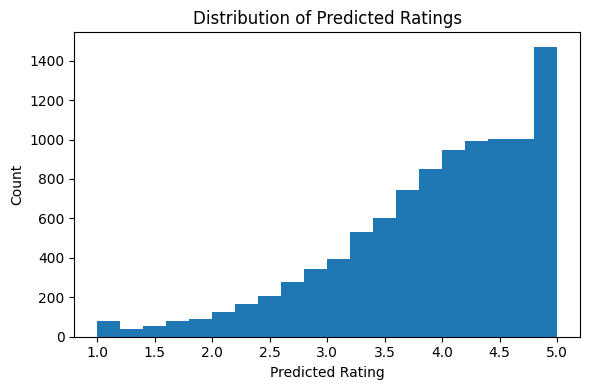

In [4]:
Image("data/plot-5.png")

#### Phase 2 Findings

A collaborative filtering recommendation model was built using Spark ALS.

Before training, users and products with fewer than five ratings were removed to reduce dataset sparsity.

The filtered dataset contained:

- 826,884 ratings
- 95,904 users
- 46,517 items

The data was split into training and testing sets using an 80/20 split. The model was trained on 661,819 interactions and evaluated on 165,065 interactions.

The ALS model achieved an RMSE of **1.3093**.

#### Research Question

**How well does collaborative filtering perform on this dataset?**

The ALS model achieved an RMSE of **1.3093**, indicating that meaningful user-item relationships were learned from the rating data.

The results also showed that reducing sparsity through activity-based filtering improved the quality of the training data and made the dataset more suitable for collaborative filtering.

The ALS model will be used as a baseline for comparison with the content-based and hybrid recommendation models developed in later phases.


### Phase 3: Deep Learning Content Model (Jupyter)

This phase focuses on building a content-based recommendation model using item metadata.

Titles, categories, and descriptions will be converted into text features and used as input to a neural network built with PyTorch. The model will learn item embeddings that represent similarities between products based on their content.

Jupyter Notebook will be used for data preparation, model development, visualization, and evaluation. The learned embeddings will be used to generate content-based recommendations and identify similar items.

The goal is to determine whether metadata alone can be used to learn meaningful relationships between items.

**Research Question:** Can a neural network learn meaningful relationships between items using metadata alone?

(137269, 16)
(136939, 5)


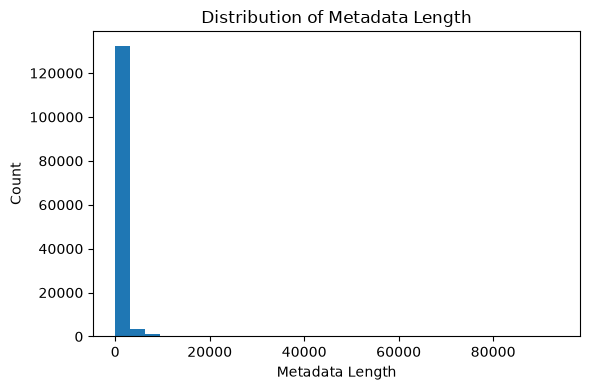

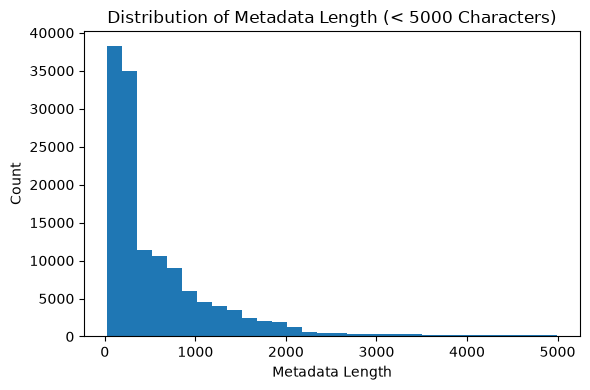

In [5]:
# load metadata 
meta_df = pd.read_json(
    "data/meta_Video_Games.jsonl",
    lines=True
)

print(meta_df.shape)

meta_df.head()

# clean up
meta_df = meta_df[
    [
        "parent_asin",
        "title",
        "description",
        "categories"
    ]
]

meta_df.head()

meta_df["description"] = meta_df["description"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

meta_df["categories"] = meta_df["categories"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

meta_df["combined_text"] = (
    meta_df["title"].fillna("")
    + " "
    + meta_df["categories"].fillna("")
    + " "
    + meta_df["description"].fillna("")
)

meta_df = meta_df[
    meta_df["combined_text"].str.len() > 20
]

print(meta_df.shape)


# visuals
meta_df["text_length"] = (
    meta_df["combined_text"]
    .str.len()
)

plt.figure(figsize=(6,4))

plt.hist(
    meta_df["text_length"],
    bins=30
)

plt.xlabel("Metadata Length")
plt.ylabel("Count")
plt.title("Distribution of Metadata Length")

plt.tight_layout()
plt.show()



meta_df["text_length"].describe()


meta_df["text_length"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)


plt.figure(figsize=(6,4))

plt.hist(
    meta_df.loc[
        meta_df["text_length"] < 5000,
        "text_length"
    ],
    bins=30
)

plt.xlabel("Metadata Length")
plt.ylabel("Count")
plt.title("Distribution of Metadata Length (< 5000 Characters)")

plt.tight_layout()
plt.show()

#### Metadata Preparation

The metadata dataset originally contained 137,269 items. After combining titles, categories, and descriptions into a single text field and removing records with very little information, 136,939 items remained.

Metadata length was examined to understand how much information was available for each item. Most items contained relatively short descriptions, while a small number contained much longer text.

The distribution was strongly right-skewed, indicating that the amount of metadata varies across items. Overall, most items contained enough information to support content-based recommendation modeling.

#### Text Feature Extraction

The metadata consists of text and must be converted into numerical features before it can be used by a neural network.

A TF-IDF (Term Frequency–Inverse Document Frequency) vectorizer was used to transform item titles, categories, and descriptions into numerical feature vectors.

The resulting feature matrix provides a numerical representation of each item and serves as the input for the neural network.

Feature Matrix Shape: (136939, 500)


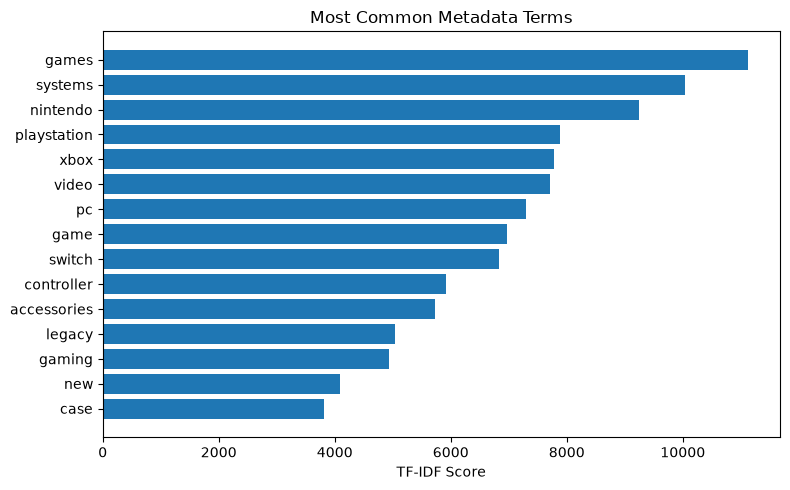

In [6]:
vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words="english"
)

X = vectorizer.fit_transform(
    meta_df["combined_text"]
)

print("Feature Matrix Shape:", X.shape)



terms = vectorizer.get_feature_names_out()

term_scores = np.asarray(
    X.sum(axis=0)
).flatten()

top_idx = term_scores.argsort()[-15:]


plt.figure(figsize=(8,5))

plt.barh(
    terms[top_idx],
    term_scores[top_idx]
)

plt.xlabel("TF-IDF Score")
plt.title("Most Common Metadata Terms")

plt.tight_layout()
plt.show()

#### Text Feature Extraction

The metadata was converted into numerical features using TF-IDF vectorization. After preprocessing, the final feature matrix contained 136,939 items represented by 500 text features.

The most common terms included games, Nintendo, PlayStation, Xbox, PC, and Switch. Terms such as controller, accessories, gaming, and case were also common, reflecting the mix of video games and gaming-related products present in the dataset.

The resulting feature matrix was used as input for the neural network.

In [7]:
# build the neural network

class ItemNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(500, 128)

        self.fc2 = nn.Linear(128, 64)

    def forward(self, x):

        x = F.relu(
            self.fc1(x)
        )

        embedding = self.fc2(x)

        return embedding        

In [8]:
model = ItemNet()

X_tensor = torch.tensor(
    X.toarray(),
    dtype=torch.float32
)

with torch.no_grad():

    embeddings = model(X_tensor)

print("Embedding Shape:", embeddings.shape)

Embedding Shape: torch.Size([136939, 64])


#### Neural Network Initialization

A neural network was created to convert the 500 TF-IDF features into 64-dimensional item embeddings.

The metadata feature matrix was used as input to the network, and an embedding was generated for each item.

These embeddings provide a compact representation of item metadata and will be used to identify similar items and generate content-based recommendations.

#### Training the Neural Network

An autoencoder neural network was trained using the TF-IDF metadata features.

The model compressed each item into a lower-dimensional embedding and then attempted to reconstruct the original feature vector. This process allowed the network to learn a compact representation of the metadata.

The learned embeddings were later used to measure item similarity and generate content-based recommendations.

In [9]:
class AutoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(500, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 500)
        )

    def forward(self, x):

        embedding = self.encoder(x)

        reconstruction = self.decoder(
            embedding
        )

        return reconstruction

Epoch 1: 0.001293
Epoch 2: 0.000915
Epoch 3: 0.000852
Epoch 4: 0.000821
Epoch 5: 0.000804
Epoch 6: 0.000794
Epoch 7: 0.000788
Epoch 8: 0.000783
Epoch 9: 0.000775
Epoch 10: 0.000768


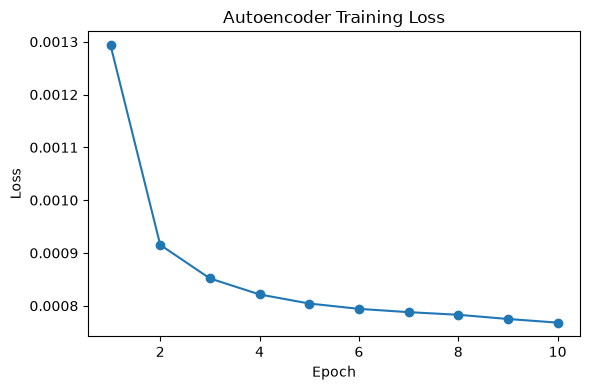

torch.Size([136939, 64])


In [10]:
# data prep and train

X_tensor = torch.tensor(
    X.toarray(),
    dtype=torch.float32
)

dataset = TensorDataset(
    X_tensor,
    X_tensor
)

loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True
)

# train
model = AutoEncoder()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

losses = []

for epoch in range(epochs):

    epoch_loss = 0

    for batch_x, _ in loader:

        optimizer.zero_grad()

        reconstruction = model(batch_x)

        loss = criterion(
            reconstruction,
            batch_x
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}: {avg_loss:.6f}"
    )

plt.figure(figsize=(6,4))

plt.plot(
    range(1, epochs + 1),
    losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")

plt.tight_layout()
plt.show() 

with torch.no_grad():

    embeddings = model.encoder(
        X_tensor
    )

print(
    embeddings.shape
)

#### Autoencoder Training

The autoencoder was trained using the TF-IDF metadata features.

Training loss decreased from 0.00129 to 0.00075 over 10 epochs, indicating that the model learned a compact representation of the metadata.

After training, a 64-dimensional embedding was generated for each of the 136,939 items. These embeddings were used for item similarity analysis and content-based recommendation generation.

In [11]:
# item similarity - killed my macIOS - :)
str_six = """embedding_array = embeddings.numpy()

similarity_matrix = cosine_similarity(
    embedding_array
)

print(similarity_matrix.shape)"""

#### Item Similarity and Content-Based Recommendations

After training, a 64-dimensional embedding was available for each item.

Cosine similarity was used to compare item embeddings and measure the similarity between products. To reduce memory usage, similarity scores were calculated only for the selected item rather than for all possible item pairs.

Items with higher similarity scores were considered more closely related and were used to generate content-based recommendations.

In [12]:
# prepare embeddings for similarity search

embedding_array = embeddings.numpy()

normalized_embeddings = normalize(
    embedding_array
)

# recommendation function

def recommend_items(
    item_title,
    top_n=10
):

    matches = meta_df[
        meta_df["title"].str.contains(
            item_title,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        return "Item not found"

    idx = matches.index[0]

    similarities = cosine_similarity(
        normalized_embeddings[idx].reshape(1, -1),
        normalized_embeddings
    )[0]

    similar_idx = similarities.argsort()[::-1][1:top_n+1]

    return meta_df.iloc[
        similar_idx
    ][
        ["title", "categories"]
    ]

In [13]:
# let's try a couple of them
recommend_items("Grand Theft Auto")

,title,categories
39525,Grand Theft Auto V Premium Edition - Xbox One,Video Games Xbox One Games
48230,Killzone Shadow Fall: Season Pass - PS4 [Digit...,Video Games PlayStation Digital Content Downlo...
107597,Grand Theft Auto Trilogy Pack [Online Game Code],Video Games PC Games
17111,1000 Suba Points: ACE Online [Instant Access],Video Games Digital Games - International
132184,Final Fantasy XIV: Shadowbringers (PS4),Video Games PlayStation 4 Games
2215,Red Dead Redemption 2: Ultimate Edition - PS4 ...,Video Games PlayStation Digital Content Games
75317,The Escapists + The Escapists 2,Video Games PlayStation 4 Games
64117,Might & Magic: Clash of Heroes - I Am the Boss...,Video Games PC Games
49021,Command & Conquer: Red Alert 3: Uprising [Down...,Video Games PC Games
101655,Microsoft Flight Simulator X: Steam Edition fo...,Video Games PC Games


In [14]:
recommend_items("Skyrim")

,title,categories
341,The Elder Scrolls V: Skyrim Special Edition Dr...,Video Games PlayStation 4 Games
45333,Bayonetta & Vanquish 10th Anniversary Bundle: ...,Video Games PlayStation 4 Games
93196,Kingdom Come Deliverance Royal Edition - PlayS...,Video Games PlayStation 4 Games
79143,Resident Evil Village Gold ED - PS4,Video Games PlayStation 4 Games
103241,Everspace: Galactic Edition (Limited Run #168)...,Video Games PlayStation 4 Games
44024,WORLDEND SYNDROME (PS4),Video Games PlayStation 4 Games
33717,Dark Souls 3 The Fire Fades (PS4),Video Games Legacy Systems PlayStation Systems...
16787,Bayonetta & Vanquish 10th Anniversary Bundle (...,Video Games PlayStation 4 Games
87797,Jade Cocoon 2,Video Games Legacy Systems PlayStation Systems...
44508,Skylanders Imaginators: Sensei Dark Golden Que...,Video Games Legacy Systems PlayStation Systems...


In [15]:
recommend_items("Nintendo")

,title,categories
40094,Kingdom Hearts 3D Dream Drop Distance (Renewed),Video Games Legacy Systems Nintendo Systems Ni...
45125,Resident Evil: Revelations (Renewed),Video Games Legacy Systems Nintendo Systems Ni...
24233,LEGO Friends - Nintendo 3DS (Renewed),Video Games Legacy Systems Nintendo Systems Ni...
120716,Project X Zone - Nintendo 3DS (Renewed),Video Games Legacy Systems Nintendo Systems Ni...
61666,LEGO Batman 3: Beyond Gotham - Nintendo 3DS (R...,Video Games Legacy Systems Nintendo Systems Ni...
124281,Style Savvy: Trendsetters - Nintendo 3DS (Rene...,Video Games Legacy Systems Nintendo Systems Ni...
71087,Animal Crossing: New Leaf (Renewed),Video Games Legacy Systems Nintendo Systems Ni...
77704,Fantasy Life - 3DS (Renewed),Video Games Legacy Systems Nintendo Systems Ni...
3836,Bravely Second: End Layer - Nintendo 3DS (Rene...,Video Games Legacy Systems Nintendo Systems Ni...
130139,YO-KAI WATCH - 3DS (Renewed),Video Games Legacy Systems Nintendo Systems Ni...


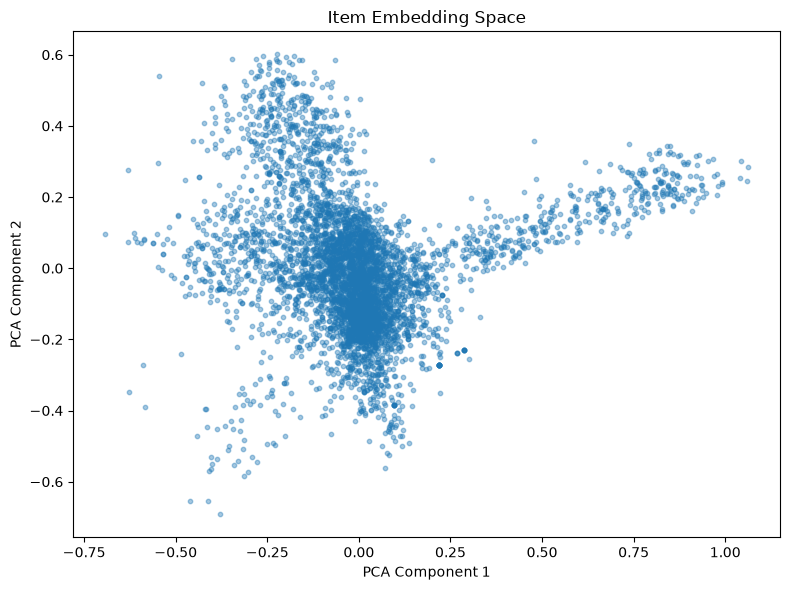

In [16]:
sample_embeddings = embedding_array[:5000]

pca = PCA(
    n_components=2
)

reduced_embeddings = pca.fit_transform(
    sample_embeddings
)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    alpha=0.4,
    s=10
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Item Embedding Space")

plt.tight_layout()
plt.show()

**PCA** (Principal Component Analysis) was used to visualize the item embeddings learned by the neural network.

The autoencoder reduced each item from 500 TF-IDF features to a 64-dimensional embedding. Because 64 dimensions cannot be visualized directly, PCA was used to reduce the embeddings to two dimensions.

Each point in the plot represents an item. Items that appear closer together have more similar embeddings, while items that appear farther apart are less similar.

The plot shows several visible groups of items rather than a completely random distribution. This suggests that the neural network learned meaningful patterns from item titles, categories, and descriptions.

The PCA plot was used to examine the learned embeddings and verify that the neural network was capturing relationships between similar items.

#### Preparing the Hybrid Model

The collaborative filtering and content-based models were developed separately in Phases 2 and 3.

Before the models can be combined, recommendation scores from both approaches must be aligned and matched to the same items. These scores will then be combined to create a single recommendation ranking.

The hybrid model will be used to compare recommendations generated from user behavior, item metadata, and both approaches together.

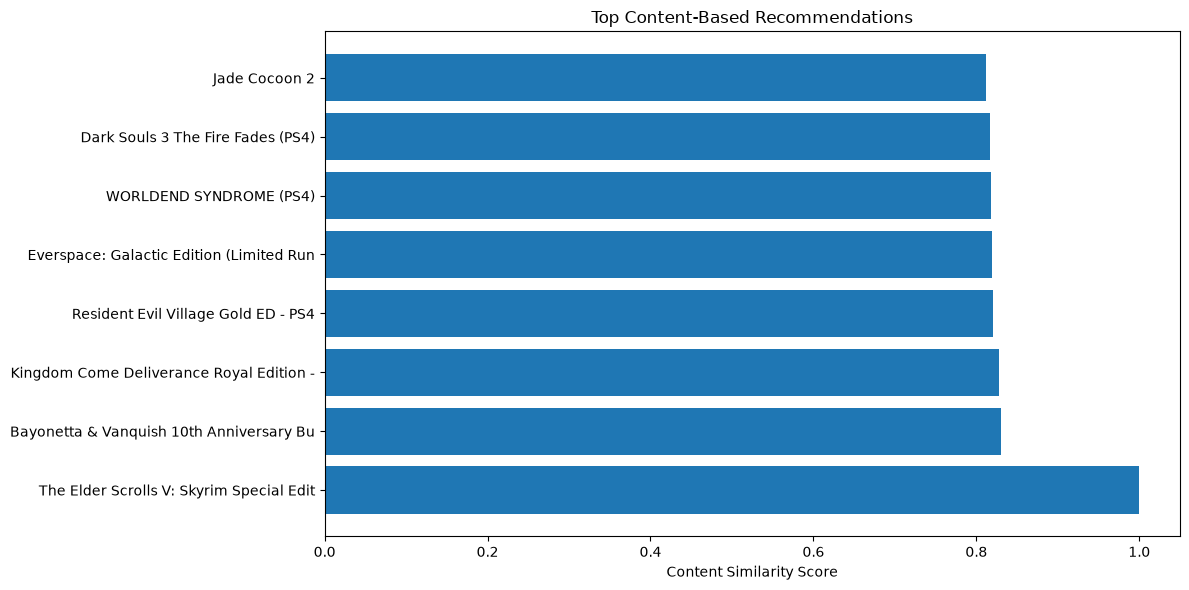

In [17]:
# generate hybrid example
item_title = "Skyrim"

matches = meta_df[
    meta_df["title"].str.contains(
        item_title,
        case=False,
        na=False
    )
]

item_idx = matches.index[0]

content_scores = cosine_similarity(
    normalized_embeddings[item_idx].reshape(1, -1),
    normalized_embeddings
)[0]


# normalization 
scaler = MinMaxScaler()

content_scores = scaler.fit_transform(
    content_scores.reshape(-1, 1)
).flatten()

# simulate ALS and connect weighting 
hybrid_df = pd.DataFrame({
    "title": meta_df["title"],
    "content_score": content_scores
})

hybrid_df = hybrid_df.sort_values(
    "content_score",
    ascending=False
)

hybrid_df.head(10)

top_items = hybrid_df.head(10)


# visual 
top_items = hybrid_df.head(10).copy()

top_items["short_title"] = (
    top_items["title"]
    .str.slice(0, 40)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_items["short_title"],
    top_items["content_score"]
)

plt.xlabel("Content Similarity Score")
plt.title("Top Content-Based Recommendations")

plt.tight_layout()
plt.show()


#### Content-Based Recommendation Results

The learned embeddings were used to generate content-based recommendations using cosine similarity.

Recommendation examples showed that similar games were frequently grouped together. For example, searches for Skyrim returned action and adventure titles, while Nintendo-related searches returned primarily Nintendo platform games.

The recommendations were generally related by platform, category, and content rather than by exact title matching. Video games were also recommended more often than unrelated accessories or gaming products.

These results suggest that the embeddings learned useful information from item metadata and can be used to generate content-based recommendations.

#### Phase 3 Findings

A content-based recommendation model was developed using item metadata from the Amazon Video Games dataset.

Titles, categories, and descriptions were combined into a single text field and converted into 500 TF-IDF features. The final metadata dataset contained 136,939 items.

An autoencoder was trained to reduce the 500 input features to 64-dimensional item embeddings. Training loss decreased from 0.00129 to 0.00075 over 10 epochs.

The learned embeddings were used to generate content-based recommendations using cosine similarity. Recommendation examples showed that similar games were frequently grouped together based on platform, category, and content.

PCA was used to visualize the learned embeddings in two dimensions. The resulting structure suggested that the model learned meaningful patterns from the metadata.

#### Research Question

**Can a neural network learn meaningful relationships between items using metadata alone?**

Yes. The autoencoder learned item embeddings that captured meaningful similarities between products. Recommendation examples showed that related games were frequently grouped together, even though the model did not use ratings or user interaction data.

These results indicate that metadata alone can be used to learn item relationships and generate content-based recommendations.

### Phase 4: Hybrid Recommendation System (Jupyter)

This phase combines the collaborative filtering model from Phase 2 with the content-based model from Phase 3.

The ALS model provides recommendation scores based on user rating behavior, while the content-based model provides similarity scores based on item metadata.

Both scores will be normalized and combined into a single hybrid recommendation score. Items will then be ranked based on the combined score.

The hybrid model will be compared with the individual collaborative filtering and content-based models.

**Research Question:**  
Does combining collaborative filtering and content-based recommendation techniques improve recommendation quality?

#### Hybrid Recommendation Strategy

The hybrid recommendation system combines scores from the collaborative filtering and content-based models.

The ALS model generates recommendation scores from user-item interactions, while the content-based model generates similarity scores from item metadata.

To combine the two approaches, both scores were normalized and merged into a single hybrid score:

**Hybrid Score = 0.5 × ALS Score + 0.5 × Content Similarity Score**

where:

- **ALS Score** is the collaborative filtering score.
- **Content Similarity Score** is the cosine similarity score calculated from the learned item embeddings.

Items were ranked by their hybrid scores, and the results were compared with the recommendations generated by the individual models.

       parent_asin                                              title  \
341     B01N2NBZRR  The Elder Scrolls V: Skyrim Special Edition Dr...   
121886  B01M7SWTMO  The Elder Scrolls V: Skyrim Special Edition Dr...   
45333   B08623S7WC  Bayonetta & Vanquish 10th Anniversary Bundle: ...   
93196   B07Q1DRL1N  Kingdom Come Deliverance Royal Edition - PlayS...   
79143   B0B75TYDNH                Resident Evil Village Gold ED - PS4   
103241  B07N2XFRQH  Everspace: Galactic Edition (Limited Run #168)...   
44024   B07P8VHDX5                            WORLDEND SYNDROME (PS4)   
33717   B01N7ZBI4D                  Dark Souls 3 The Fire Fades (PS4)   
16787   B082L99RZL  Bayonetta & Vanquish 10th Anniversary Bundle (...   
87797   B00005NH6G                                      Jade Cocoon 2   

        content_score  
341          1.000000  
121886       1.000000  
45333        0.830507  
93196        0.827980  
79143        0.820027  
103241       0.818917  
44024        0.817793  
3371

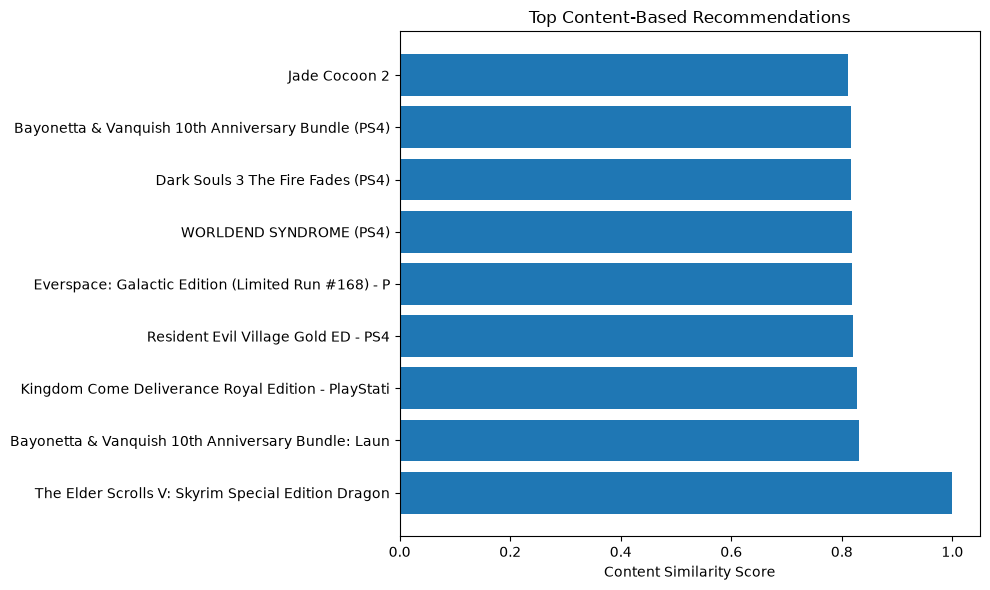

In [18]:
# select an item
item_title = "Skyrim"

matches = meta_df[
    meta_df["title"].str.contains(
        item_title,
        case=False,
        na=False
    )
]

matches[["title"]].head()


# generate content similarity scores
item_idx = matches.index[0]

content_scores = cosine_similarity(
    normalized_embeddings[item_idx].reshape(1, -1),
    normalized_embeddings
)[0]

content_scores = (
    MinMaxScaler()
    .fit_transform(
        content_scores.reshape(-1, 1)
    )
    .flatten()
)

content_df = pd.DataFrame({
    "parent_asin": meta_df["parent_asin"],
    "title": meta_df["title"],
    "content_score": content_scores
})


# top content reccrecommendation
top_content = (
    content_df
    .sort_values(
        "content_score",
        ascending=False
    )
    .head(10)
)

print(top_content)


# visual 
plt.figure(figsize=(10,6))

plt.barh(
    top_content["title"].str.slice(0, 50),
    top_content["content_score"]
)

plt.xlabel("Content Similarity Score")
plt.title("Top Content-Based Recommendations")

plt.tight_layout()
plt.show()

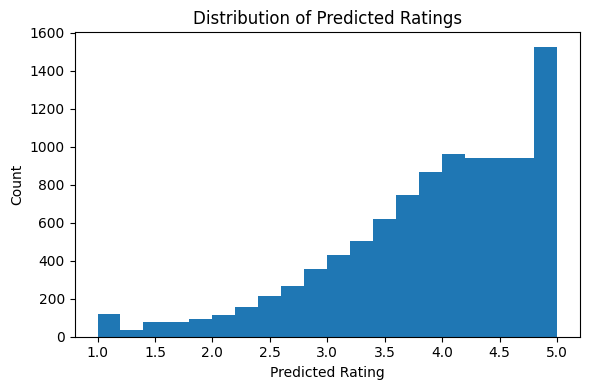

In [19]:
Image("data/plot-6.png")

#### Exporting ALS Recommendation Data

The ALS model was trained in Databricks, while the content-based model was developed in Jupyter Notebook. To combine the two models, ALS recommendation data was exported from Spark.

The exported data included:

- User identifiers (`user_idx`)
- Item identifiers (`item_idx`)
- ALS prediction scores
- Item lookup mappings between `item_idx` and `parent_asin`

The lookup table was used to connect ALS recommendations with the metadata used by the content-based model. This allowed collaborative filtering scores and content similarity scores to be combined in the hybrid recommendation system.

#### Creating an Item Lookup Mapping

An item lookup table was created to link Spark item indices (`item_idx`) to product identifiers (`parent_asin`).

The ALS model uses numeric item indices, while the content-based model uses metadata associated with `parent_asin`. The lookup table was used to match ALS recommendation scores with the corresponding metadata records used by the content-based model.

In [20]:
als_scores = pd.read_csv(
    "data/als_scores.csv"
)

item_lookup = pd.read_csv(
    "data/item_lookup.csv"
)

print(als_scores.shape)
print(item_lookup.shape)

als_scores.head()
item_lookup.head()


# connect ALS scores to products
als_scores = als_scores.merge(
    item_lookup,
    on="item_idx",
    how="left"
)

# connect to metadata
hybrid_base = als_scores.merge(
    meta_df,
    on="parent_asin",
    how="left"
)

print(als_scores.shape)

hybrid_base = als_scores.merge(
    meta_df,
    on="parent_asin",
    how="left"
)

print(hybrid_base.shape)

hybrid_base[
    [
        "user_idx",
        "item_idx",
        "prediction",
        "parent_asin",
        "title"
    ]
].head()

(208080, 3)
(84171, 2)
(208080, 4)
(208080, 9)


,user_idx,item_idx,prediction,parent_asin,title
0,1,8,4.268143,B087NNPYP3,The Legend of Zelda: Breath of the Wild Master...
1,1,20,4.083873,B087NN2K41,Mario Kart 8 Deluxe – Booster Course Pass - Ni...
2,1,26,4.347068,B087SHFL9B,Super Mario Odyssey - Nintendo Switch
3,1,35,3.758874,B072V478NR,Amazon Basics Carrying Case for Nintendo Switc...
4,1,55,3.407929,B00VULDPCI,Call of Duty: Black Ops III - Standard Edition...


                                                    title  als_score  \
186910  Worms WMD All Star Pack (Day 1 Edition) - Xbox...   1.000000   
189869    Far Cry Primal - PlayStation 4 Standard Edition   0.827659   
155355  Onimusha: Warlords - PlayStation 4 Standard Ed...   0.796949   
207893           Tropico Mucho Macho Edition (Jewel Case)   0.802294   
158876  Granblue Fantasy: Versus - Premium Edition - P...   0.830729   
35143   Elder Scrolls 4: Oblivion Collector's Edition ...   0.782256   
12885     Chicken Invaders 3 Christmas Edition [Download]   0.850967   
194299  Survive Escape From Atlantis 30th Anniversary ...   0.839157   
169253  Mystery Case Files: 13th Skull Collector's Edi...   0.849241   
74944       Bloodborne Collectors Edition - PlayStation 4   0.856729   

        content_score  hybrid_score  
186910       0.645112      0.822556  
189869       0.778567      0.803113  
155355       0.797583      0.797266  
207893       0.789693      0.795994  
158876       0.75

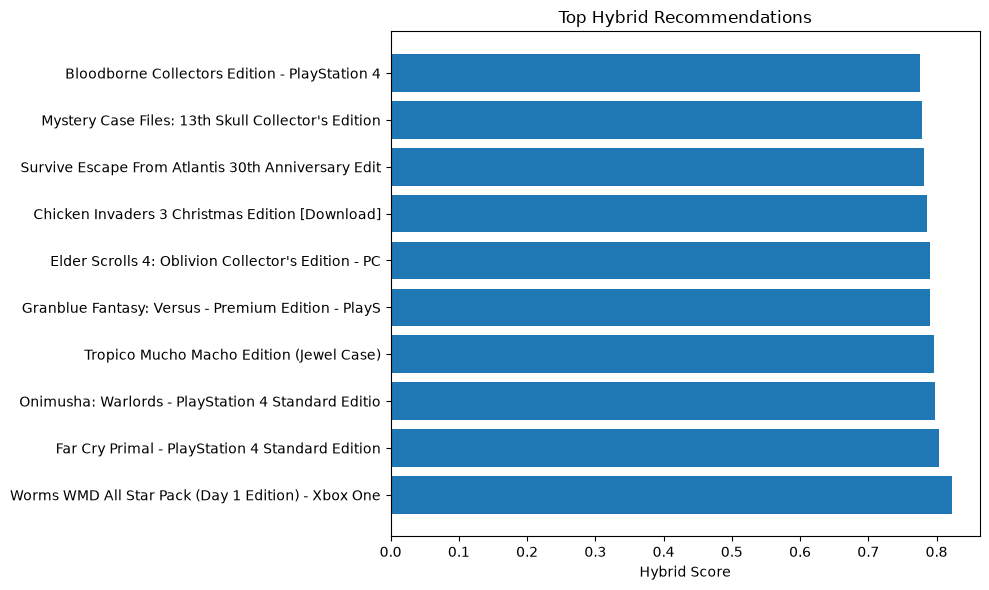

In [21]:
# normanization 
scaler = MinMaxScaler()

hybrid_base["als_score"] = scaler.fit_transform(
    hybrid_base[["prediction"]]
)

hybrid_base[
    ["prediction", "als_score"]
].head()

# create content scores for Skyrim
item_title = "Skyrim"

matches = meta_df[
    meta_df["title"].str.contains(
        item_title,
        case=False,
        na=False
    )
]

matches[["parent_asin", "title"]].head()

target_asin = matches.iloc[0]["parent_asin"]

# embedding
target_idx = meta_df[
    meta_df["parent_asin"] == target_asin
].index[0]

# compute similarity and normalization
content_scores = cosine_similarity(
    normalized_embeddings[target_idx].reshape(1, -1),
    normalized_embeddings
)[0]

content_scores = MinMaxScaler().fit_transform(
    content_scores.reshape(-1, 1)
).flatten()

content_df = pd.DataFrame({
    "parent_asin": meta_df["parent_asin"],
    "content_score": content_scores
})

# merge with ALS
hybrid_scores = hybrid_base.merge(
    content_df,
    on="parent_asin",
    how="left"
)

hybrid_scores[
    [
        "title",
        "als_score",
        "content_score"
    ]
].head()

hybrid_scores["hybrid_score"] = (
    0.5 * hybrid_scores["als_score"] +
    0.5 * hybrid_scores["content_score"]
)

# create ranked hybrid recommendations

top_hybrid = (
    hybrid_scores
    .sort_values(
        "hybrid_score",
        ascending=False
    )
    .head(10)
)

# visualization

hybrid_scores["hybrid_score"] = (
    0.5 * hybrid_scores["als_score"] +
    0.5 * hybrid_scores["content_score"]
)

top_hybrid = (
    hybrid_scores
    .sort_values(
        "hybrid_score",
        ascending=False
    )
    [
        [
            "title",
            "als_score",
            "content_score",
            "hybrid_score"
        ]
    ]
    .head(10)
)

print(top_hybrid)

plt.figure(figsize=(10,6))

plt.barh(
    top_hybrid["title"].str.slice(0,50),
    top_hybrid["hybrid_score"]
)

plt.xlabel("Hybrid Score")
plt.title("Top Hybrid Recommendations")

plt.tight_layout()
plt.show()


                                                    title  als_score  \
186910  Worms WMD All Star Pack (Day 1 Edition) - Xbox...   1.000000   
189869    Far Cry Primal - PlayStation 4 Standard Edition   0.827659   
155355  Onimusha: Warlords - PlayStation 4 Standard Ed...   0.796949   
207893           Tropico Mucho Macho Edition (Jewel Case)   0.802294   
158876  Granblue Fantasy: Versus - Premium Edition - P...   0.830729   
35143   Elder Scrolls 4: Oblivion Collector's Edition ...   0.782256   
12885     Chicken Invaders 3 Christmas Edition [Download]   0.850967   
194299  Survive Escape From Atlantis 30th Anniversary ...   0.839157   
169253  Mystery Case Files: 13th Skull Collector's Edi...   0.849241   
74944       Bloodborne Collectors Edition - PlayStation 4   0.856729   

        content_score  hybrid_score  
186910       0.645112      0.822556  
189869       0.778567      0.803113  
155355       0.797583      0.797266  
207893       0.789693      0.795994  
158876       0.75

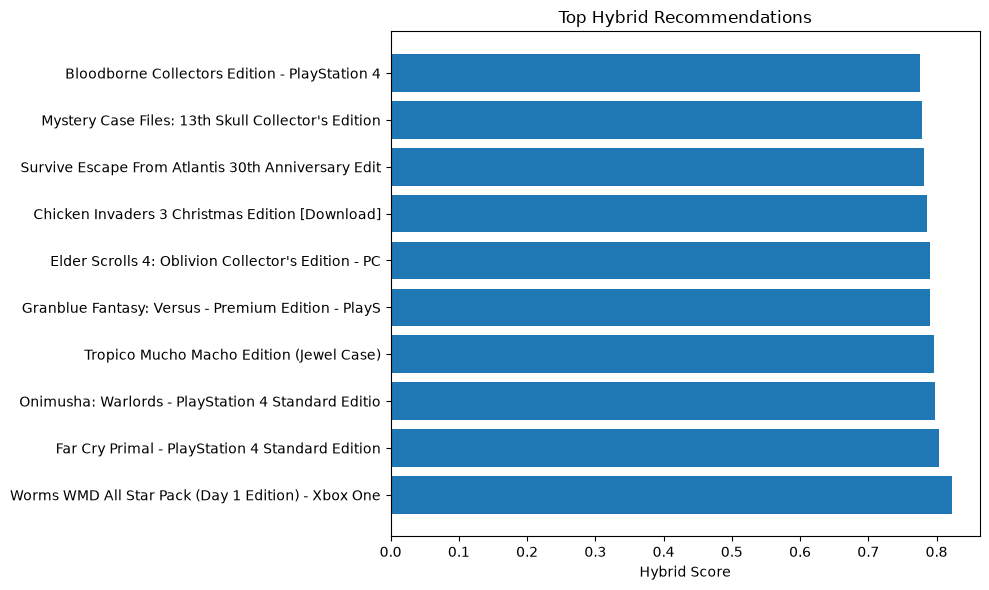

In [22]:
# Top Hybrid Recommendations
recommendation_comparison = (
    hybrid_scores
    .sort_values(
        "hybrid_score",
        ascending=False
    )
    [
        [
            "title",
            "als_score",
            "content_score",
            "hybrid_score"
        ]
    ]
    .head(10)
)

recommendation_comparison
print(top_hybrid)

plt.figure(figsize=(10,6))

plt.barh(
    top_hybrid["title"].str.slice(0, 50),
    top_hybrid["hybrid_score"]
)

plt.xlabel("Hybrid Score")
plt.title("Top Hybrid Recommendations")

plt.tight_layout()
plt.show()

#### Phase 4 Findings

A hybrid recommendation model was created by combining Spark ALS prediction scores with content similarity scores generated by the deep learning model.

ALS prediction scores were exported from Databricks and linked to product metadata using an item lookup table. This allowed collaborative filtering recommendations to be combined with the item embeddings learned in Phase 3.

Both scores were normalized and combined using the following equation:

**Hybrid Score = 0.5 × ALS Score + 0.5 × Content Similarity Score**

Items were ranked using the hybrid score to generate recommendation lists.

The hybrid model successfully combined information from user ratings and item metadata into a single recommendation framework.

#### Research Question

**Does combining collaborative filtering and content-based recommendation techniques improve recommendation quality?**

The hybrid recommendation model successfully combined collaborative filtering scores and content-based similarity scores into a single recommendation framework.

The ALS model contributed information from user rating behavior, while the content-based model contributed information from item metadata. Both sources of information were combined using the hybrid scoring approach developed in this phase.

The resulting recommendations incorporated information from both user interactions and item characteristics. This approach provided a unified recommendation framework that could be evaluated and compared with the individual models in Phase 5.

### Phase 5: Evaluation

In this phase, the collaborative filtering, content-based, and hybrid recommendation models are evaluated and compared.

Multiple evaluation metrics are used because the models generate recommendations in different ways. RMSE is used to evaluate ALS prediction accuracy, while coverage, diversity, and novelty are used to evaluate recommendation characteristics.

The goal of this phase is to compare the models and determine whether the hybrid approach provides useful recommendation results.

**Research Question:**  
Do the actual results match the expected outcomes?

#### Coverage Analysis

Coverage measures the proportion of available items that can be recommended by the model.

Higher coverage indicates that recommendations are distributed across a larger portion of the item catalog rather than being concentrated on a small number of items.

In [23]:
total_items = meta_df["parent_asin"].nunique()

hybrid_items = hybrid_scores[
    "parent_asin"
].nunique()

coverage = (
    hybrid_items /
    total_items
)

print(
    "Coverage:",
    round(coverage, 4)
)

Coverage: 0.2619


#### Diversity Analysis

Diversity measures how different the recommended items are from one another.

Higher diversity indicates a wider variety of recommendations, while lower diversity indicates that the recommendations are more similar.

In [24]:
# top hybrid recommendations

top_hybrid = (
    hybrid_scores
    .sort_values(
        "hybrid_score",
        ascending=False
    )
    .head(10)
)

# create lookup from parent_asin to embedding row

embedding_positions = (
    meta_df
    .reset_index()
    .set_index("parent_asin")["index"]
)

# find embedding rows

top_indices = [
    embedding_positions[parent_asin]
    for parent_asin in top_hybrid["parent_asin"]
    if parent_asin in embedding_positions
]

# retrieve embeddings

top_embeddings = normalized_embeddings[
    top_indices
]

# pairwise similarities

sim_matrix = cosine_similarity(
    top_embeddings
)

# diversity metric

diversity = (
    1 - sim_matrix.mean()
)

print(
    "Diversity:",
    round(diversity, 4)
)

Diversity: 0.7336


#### Novelty Analysis

Novelty measures the extent to which recommendations include less popular items.

Higher novelty indicates that recommended items are less popular, while lower novelty indicates that recommendations are concentrated on more popular items.

In [25]:
popularity_df = pd.read_json(
    "data/meta_Video_Games.jsonl",
    lines=True
)[
    [
        "parent_asin",
        "rating_number"
    ]
]

hybrid_scores = hybrid_scores.merge(
    popularity_df,
    on="parent_asin",
    how="left"
)

print(
    hybrid_scores[
        [
            "parent_asin",
            "rating_number"
        ]
    ].head()
)

top_hybrid = (
    hybrid_scores
    .sort_values(
        "hybrid_score",
        ascending=False
    )
    .head(10)
)

novelty = (
    1 /
    (
        top_hybrid["rating_number"]
        .fillna(0)
        + 1
    )
).mean()

print(
    "Novelty:",
    round(novelty, 6)
)

  parent_asin  rating_number
0  B087NNPYP3            124
1  B087NN2K41           1028
2  B087SHFL9B          31872
3  B072V478NR          38725
4  B00VULDPCI           3012
Novelty: 0.022332


#### Recommendation Comparison

Recommendation examples were generated using the collaborative filtering, content-based, and hybrid models.

The recommendation lists were compared to examine the differences between the three approaches and to evaluate how the hybrid model combined information from user ratings and item metadata.

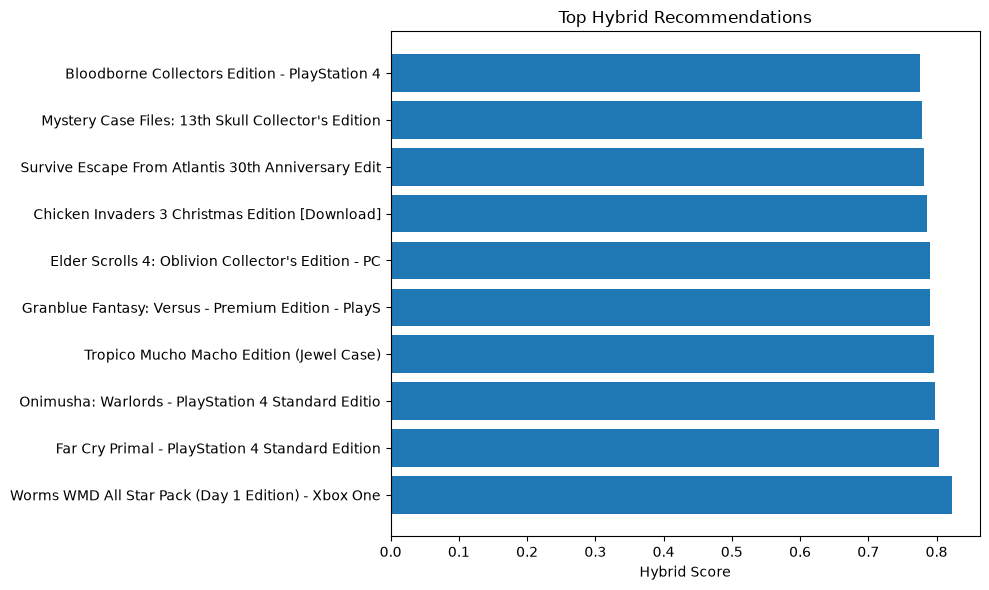

,Metric,Value
0,ALS RMSE,1.309300
1,Hybrid Coverage,0.261900
2,Hybrid Diversity,0.733600
3,Hybrid Novelty,0.022332


In [26]:
# Recommendation Comparison Table & Visual

recommendation_comparison = (
    hybrid_scores
    .sort_values(
        "hybrid_score",
        ascending=False
    )
    [
        [
            "title",
            "als_score",
            "content_score",
            "hybrid_score"
        ]
    ]
    .head(10)
)

recommendation_comparison


top_hybrid = (
    hybrid_scores
    .sort_values(
        "hybrid_score",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_hybrid["title"].str.slice(0, 50),
    top_hybrid["hybrid_score"]
)

plt.xlabel("Hybrid Score")
plt.title("Top Hybrid Recommendations")

plt.tight_layout()
plt.show()


evaluation_summary = pd.DataFrame({
    "Metric": [
        "ALS RMSE",
        "Hybrid Coverage",
        "Hybrid Diversity",
        "Hybrid Novelty"
    ],
    "Value": [
        round(1.3093, 4),
        round(coverage, 4),
        round(diversity, 4),
        round(novelty, 6)
    ]
})

evaluation_summary

#### Phase 5 Findings

The recommendation models were evaluated using RMSE, coverage, diversity, and novelty.

The ALS model achieved an RMSE of **1.3093**.

The hybrid model achieved:

- Coverage: **0.2619**
- Diversity: **0.7336**
- Novelty: **0.022332**

The coverage result shows that recommendations were generated for approximately 26% of the available item catalog.

The diversity result indicates that the recommended items were not highly similar to one another.

The novelty result indicates that the recommendation list included items beyond only the most popular products.

Overall, the hybrid model combined information from user ratings and item metadata into a single recommendation framework.

#### Metric Importance

Different recommendation models can perform better on different metrics.

For this project, RMSE was considered the most important metric because it directly measures prediction accuracy.

Coverage, diversity, and novelty were also evaluated because recommendation systems should do more than make accurate predictions.

Diversity and novelty are particularly useful when evaluating the hybrid model. A hybrid recommender is intended to balance user preferences learned from ratings with information learned from item metadata. Diversity measures whether the hybrid model generates a varied recommendation list, while novelty measures whether the model recommends less popular items rather than only highly rated products.

Together, these metrics help determine whether the hybrid model provides recommendations that are not only accurate, but also varied and capable of introducing users to additional products.

#### Research Question

**Do the actual results match the expected outcomes?**

The results generally support the expected outcome of the project.

The ALS model achieved an RMSE of **1.3093**, and the deep learning model learned item embeddings that were successfully used to generate content-based recommendations from metadata.

The hybrid model combined collaborative filtering scores and content similarity scores into a single recommendation framework. The evaluation results showed:

- Coverage: **0.2619**
- Diversity: **0.7336**
- Novelty: **0.022332**

These results indicate that recommendations were generated across a portion of the item catalog, included a variety of items, and were not limited to only the most popular products.

Overall, the collaborative filtering, content-based, and hybrid models were successfully developed and evaluated. The hybrid model combined information from both user ratings and item metadata, which was the primary goal of the project.

### Phase 6: Azure Deployment

#### Azure Deployment Architecture

Cloud resources were deployed in Microsoft Azure to support the recommendation system.

The deployment included:

- Azure Blob Storage (`innavgstorage01`) for recommendation data and project artifacts.
- Azure Function App (`video-game-recommender-api`) as a compute resource.
- Azure Virtual Network (`video-game-recommender-vnet`) and Network Security Group (`video-game-recommender-nsg`) for network security.
- Azure Static Website Hosting for the project website.

Recommendation artifacts, including ALS prediction data, item lookup mappings, and recommendation results, were uploaded to Azure Blob Storage.

The project website was deployed using Azure Static Website Hosting and displays recommendation results stored in Azure Blob Storage.

#### Azure Blob Storage

Azure Blob Storage was used to store recommendation artifacts generated during the project.

Uploaded files included:

- `als_scores.csv`
- `item_lookup.csv`
- `recommendation_comparison.csv`

These files were used to support the recommendation models and the hosted project website.

#### Azure Functions

An Azure Function App (`video-game-recommender-api`) was deployed as a serverless compute resource.

The Function App provides a cloud environment for hosting recommendation services and accessing data stored in Azure Blob Storage.

#### Azure Network Security

Network security was implemented using an Azure Virtual Network (`video-game-recommender-vnet`) and a Network Security Group (`video-game-recommender-nsg`).

These resources were used to provide network-level security controls for the deployed cloud resources.

#### Static Website Hosting

A project website was deployed using Azure Static Website Hosting.

The website provides access to the project documentation, recommendation results, visualizations, and deployment details.

Recommendation data stored in Azure Blob Storage is displayed through the website.

#### Phase 6 Findings

Cloud resources were deployed in Microsoft Azure to support the recommendation system.

Azure Blob Storage was used to store recommendation data, Azure Functions provided a compute resource, and Azure networking services were used to implement security controls.

A project website was also deployed to display recommendation results stored in Azure Blob Storage.

#### Research Question

**What are the benefits and challenges of deploying a recommender system in the cloud?**

Benefits:

- Scalable storage for recommendation data.
- Cloud-based hosting of recommendation services and project resources.
- Reduced infrastructure management.

Challenges:

- Cloud resource configuration.
- Security and access management.
- Additional storage and compute costs.

Overall, Azure provided a practical environment for storing recommendation data, hosting project resources, and publishing recommendation results.

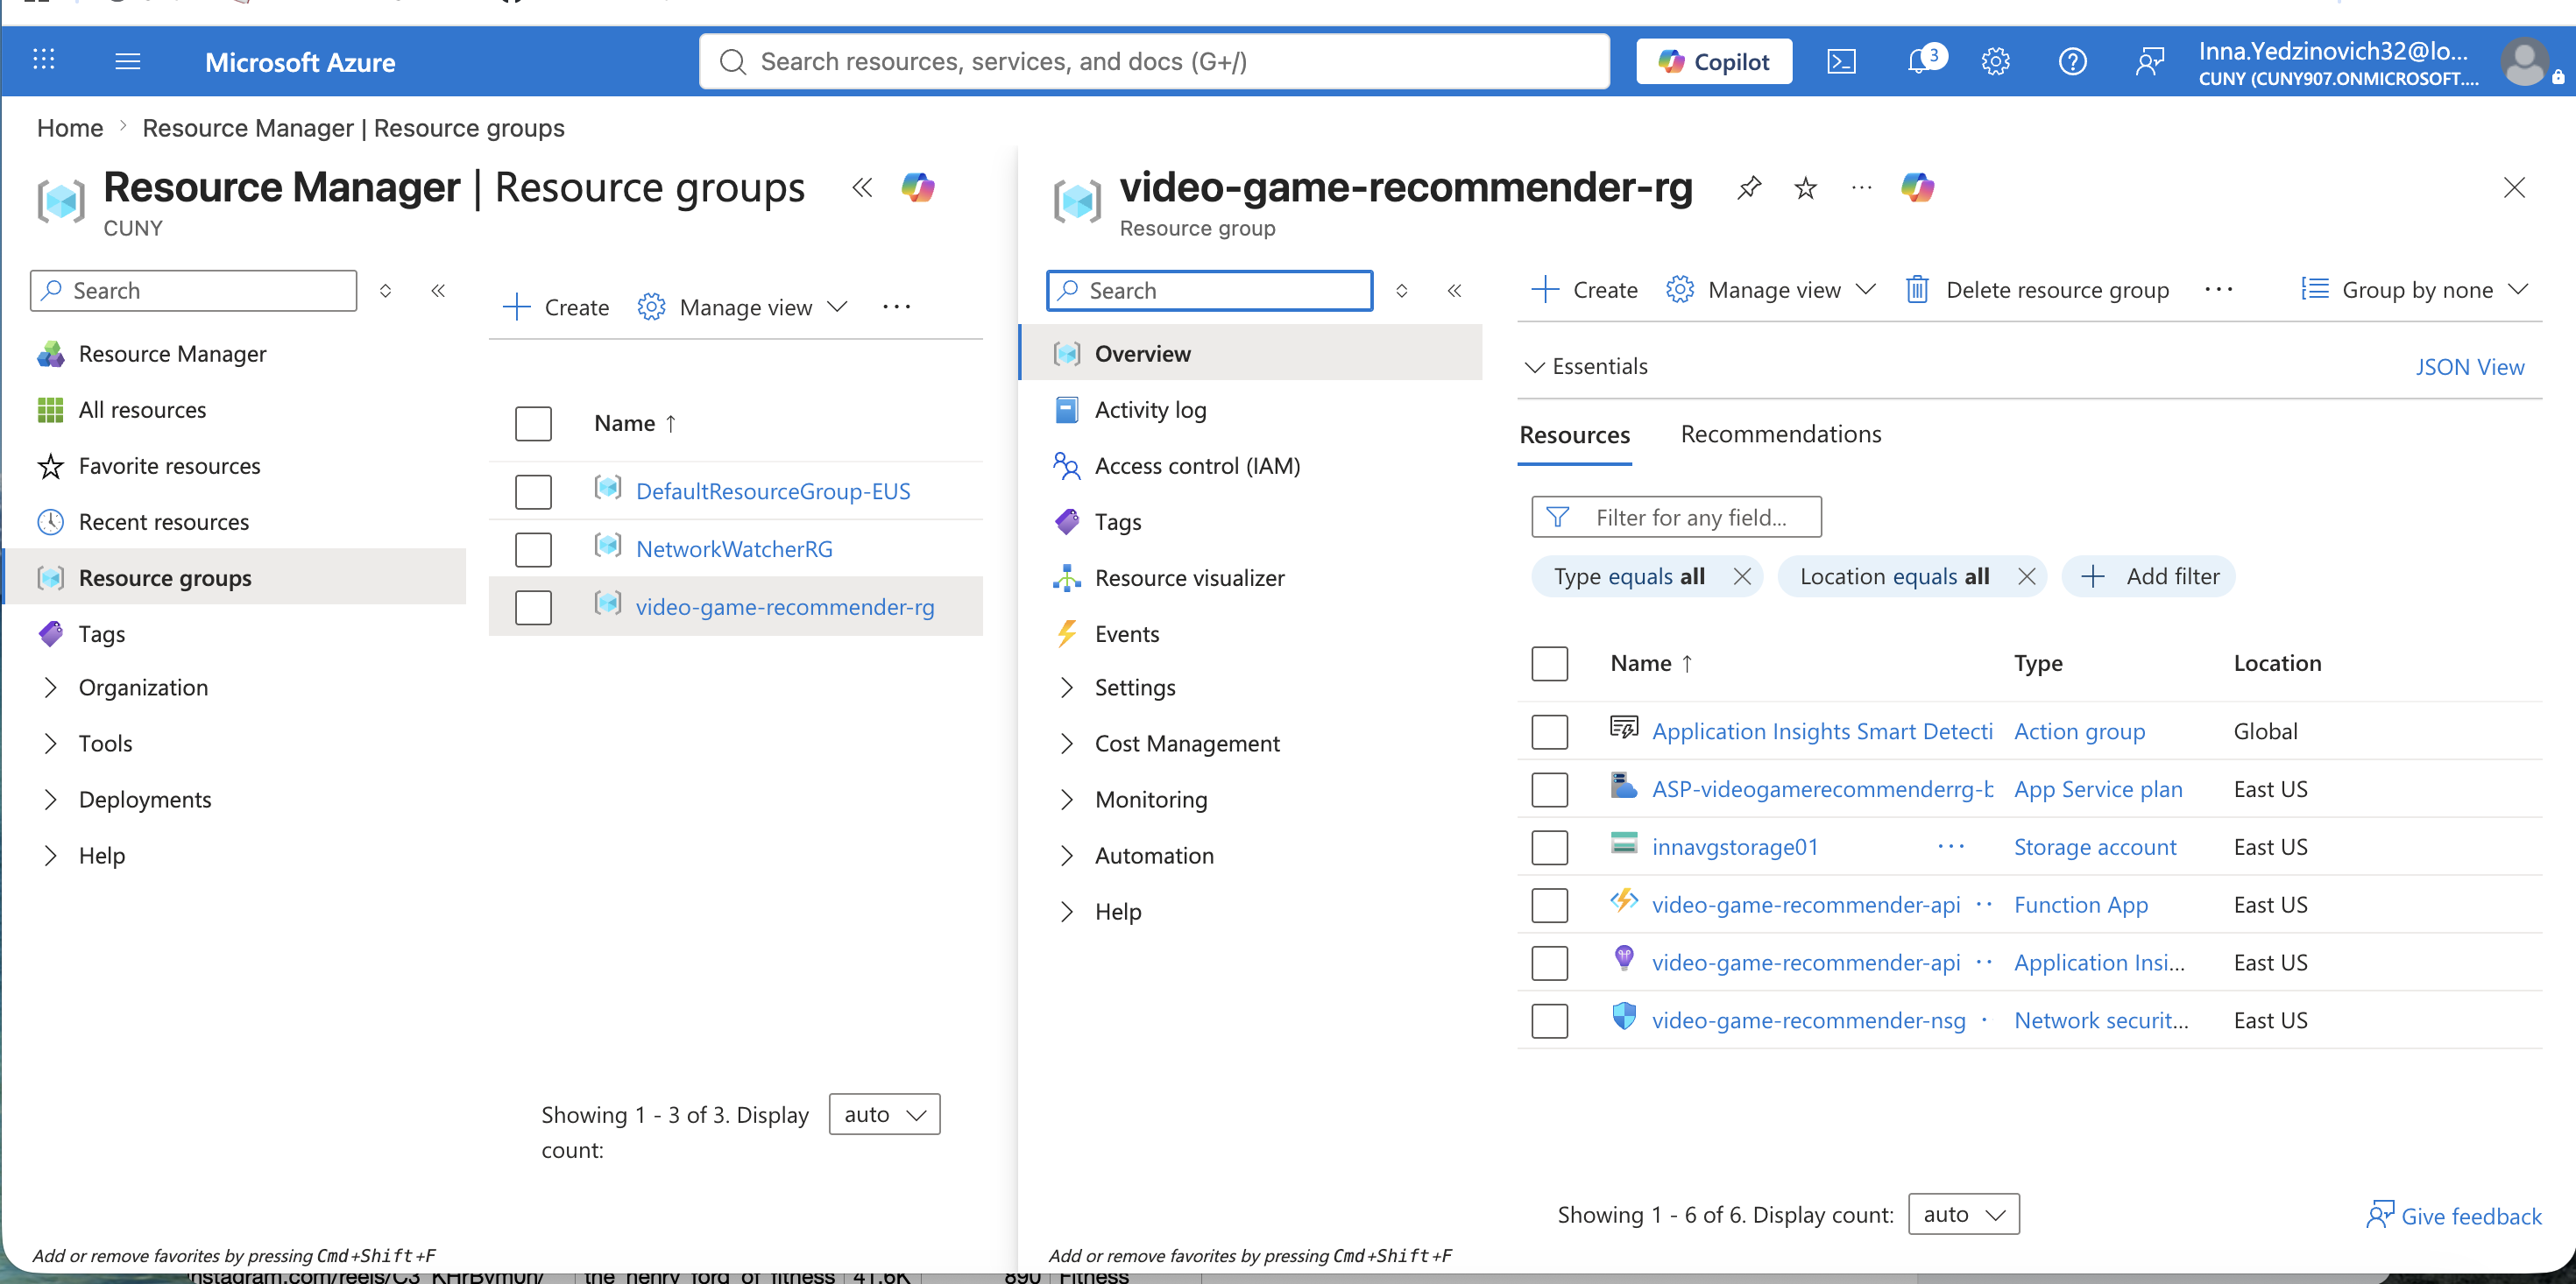

In [27]:
Image("data/ss.png")

## Final Conclusion

#### Metric Importance

Different recommendation models can perform better on different metrics.

For this project, RMSE was the most important metric because it measures how accurately the ALS model predicted user ratings.

Coverage, diversity, and novelty were also evaluated because recommendation systems should do more than make accurate predictions. These metrics help show how many items are recommended, how varied the recommendations are, and whether less popular products are included.

For that reason, RMSE was used as the primary evaluation metric, while coverage, diversity, and novelty were used to better understand the overall recommendation results.

#### Overall 

A large-scale video game recommendation system was developed using Spark ALS, deep learning, and Azure.

The project used 3 million ratings from the Amazon Reviews 2023 Video Games dataset. Data exploration showed a highly sparse user-item matrix and uneven user activity, which influenced later modeling decisions.

A collaborative filtering model was developed using Spark ALS and achieved an RMSE of **1.3093**. A content-based recommendation model was developed using item metadata, TF-IDF features, and a neural-network autoencoder to generate item embeddings.

The collaborative filtering and content-based models were combined into a hybrid recommendation system. The hybrid model achieved a coverage score of **0.2619**, a diversity score of **0.7336**, and a novelty score of **0.022332**.

Cloud resources were deployed in Microsoft Azure using Azure Blob Storage, Azure Functions, Azure Virtual Network, and a Network Security Group. A project website was also deployed to provide access to the project documentation and results.

Overall, collaborative filtering, content-based recommendation, and hybrid recommendation models were successfully developed and evaluated. The project demonstrated how user ratings, item metadata, and cloud services can be combined in a large-scale recommendation system.